In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from functools import cached_property

# Update pandas display options
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 250)

class BSOption:
    """Base class for Black-Scholes option calculations with Greeks."""
    def __init__(self, K: float, r: float, sigma: float, T: float):
        """
        Args:
            K: Strike price
            r: Risk-free rate (annualized)
            sigma: Volatility (annualized)
            T: Time to expiration (years)
        """
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        
    def _d1(self, S: float, t: float) -> float:
        return (np.log(S/self.K) + (self.r + 0.5 * self.sigma**2)*t) / (self.sigma*np.sqrt(t))
    
    def delta(self, S: float, t: float) -> float:
        return norm.cdf(self._d1(S, t))
    
    def gamma(self, S: float, t: float) -> float:
        d1 = self._d1(S, t)
        return norm.pdf(d1) / (S * self.sigma * np.sqrt(t))
    
    def charm(self, S: float, t: float) -> float:
        """Option charm (delta decay): sensitivity of delta to the passage of time."""
        if t <= 1e-6:
            return 0.0
        d1 = self._d1(S, t)
        pdf = norm.pdf(d1)
        term1 = (self.r + 0.5*self.sigma**2) / (self.sigma*np.sqrt(t))
        term2 = d1 / (2*t)
        return -pdf * (term1 - term2)
    
class DeltaSimulator(BSOption):
    """Simulates delta differences under price moves using Monte Carlo."""
    def __init__(self, K: float, r: float, sigma: float, T: float, delta_t: float, mu: float = 0.07, N_MC: int = 100000):
        super().__init__(K, r, sigma, T)
        self.delta_t = delta_t  # one-day time step
        self.mu = mu
        self.sigma_d = sigma * np.sqrt(delta_t)
        self.N_MC = N_MC
        
    @cached_property
    def RN(self) -> np.ndarray:
        return np.random.randn(self.N_MC)
    
    @property
    def default_canvas(self):
        """
        Returns a styled (fig, ax) tuple:
          - Figure size: 10 x 6 inches.
          - Figure background: light beige (#F5F5DC).
          - Axes background: lighter beige (#FAF0E6).
        """
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('#F5F5DC')
        ax.set_facecolor('#FAF0E6')
        return fig, ax
    
    def _implied_S0(self, initial_delta: float) -> float:
        """
        Calculate the implied initial stock price S₀ from the given initial delta.
        """
        d1_value = norm.ppf(initial_delta)
        return self.K * np.exp(d1_value * self.sigma * np.sqrt(self.T) - (self.r + 0.5*self.sigma**2)*self.T)
    
    def simulate(self, initial_delta: float) -> pd.Series:
        """
        Simulate delta differences across price move thresholds.
        
        Args:
            initial_delta: Target initial delta value
            
        Returns:
            pd.Series: Mean delta differences indexed by price deviation
        """
        S0 = self._implied_S0(initial_delta)
        print(f"Implied initial S0 from Δ0={initial_delta:.2f}: {S0:.3f}")

        # Generate price paths using the cached random normals.
        S1 = S0 * np.exp(
            (self.mu - 0.5*self.sigma**2)*self.delta_t +
            self.sigma*np.sqrt(self.delta_t)*self.RN
        )

        # Calculate delta differences.
        D0 = self.delta(S0, self.T)
        D1 = self.delta(S1, self.T - self.delta_t)
        delta_diff = D1 - D0

        # Define sigma-level thresholds.
        sigma_levels = np.arange(-6, 6.05, 0.1)
        mask_neg = sigma_levels < 0
        mask_pos = sigma_levels > 0

        thresholds_neg = S0 * (1 + sigma_levels[mask_neg] * self.sigma_d)
        thresholds_pos = S0 * (1 + sigma_levels[mask_pos] * self.sigma_d)
        all_thresholds = np.concatenate([thresholds_neg, thresholds_pos])

        # Vectorized boundary checks.
        S1_expanded = S1.reshape(1, -1)
        neg_masks = (S1_expanded >= thresholds_neg.reshape(-1, 1)) & (S1 < S0)
        pos_masks = (S1_expanded <= thresholds_pos.reshape(-1, 1)) & (S1 > S0)
        all_masks = np.vstack([neg_masks, pos_masks])

        # Calculate means for each threshold.
        means = [
            delta_diff[mask_row].mean() if mask_row.any() else np.nan
            for mask_row in all_masks
        ]
        res = pd.Series(
            means,
            index=all_thresholds - S0,
            name='Δ Difference'
        ).sort_index().dropna()
        return res
    
    def simulate_multiple(self, initial_deltas: list) -> pd.DataFrame:
        """
        For each initial delta, run simulation and interpolate results onto a common grid.
        Returns a DataFrame with one column per initial delta.
        """
        sim_results = {}
        for d in initial_deltas:
            series = self.simulate(d)
            key = f"Δ₀={d} (S₀={self._implied_S0(d):.2f})"
            sim_results[key] = series
        all_indices = np.concatenate([s.index.values for s in sim_results.values()])
        global_min = all_indices.min()
        global_max = all_indices.max()
        common_grid = np.linspace(global_min, global_max, 200)
        interpolated = {}
        for key, series in sim_results.items():
            new_vals = np.interp(common_grid, series.index.values, series.values)
            interpolated[key] = pd.Series(new_vals, index=common_grid, name=key)
        return pd.DataFrame(interpolated)
    
    def initial_charm_change(self, initial_delta: float) -> float:
        """
        Compute the one-day change in delta due solely to option charm at the option's initial S₀.
        Returns: Δ_charm = charm(S₀, T - delta_t) * delta_t.
        """
        S0 = self._implied_S0(initial_delta)
        return self.charm(S0, self.T - self.delta_t) * self.delta_t
    
    def summary_initial_greeks(self, initial_deltas: list) -> pd.DataFrame:
        """
        Build a summary table (indexed by initial delta) listing:
          - Implied S₀,
          - Calculated Delta (at S₀, T),
          - Gamma (at S₀, T), and
          - One-day Charm-induced Δ change.
        """
        summary_data = []
        for d in initial_deltas:
            S0 = self._implied_S0(d)
            delta_val = self.delta(S0, self.T)
            gamma_val = self.gamma(S0, self.T)
            charm_val = self.initial_charm_change(d)
            summary_data.append({
                "Initial Delta": d,
                "Implied S₀": S0,
                "Calculated Delta": delta_val,
                "Initial Gamma": gamma_val,
                "Initial Charm": charm_val
            })
        return pd.DataFrame(summary_data).set_index("Initial Delta")
    
    def gamma_charm_approximation(self, initial_delta: float) -> pd.Series:
        """
        For a given initial delta, compute the gamma-charm approximation of delta change for stock moves 
        over a one-day period, for moves up to 5-sigma.
        For each price deviation dS in a grid from -5*sigma_d to 5*sigma_d, compute:
            Approximation = gamma(S₀,T)*dS + charm(S₀,T)*delta_t.
        Returns a pd.Series indexed by dS.
        """
        S0 = self._implied_S0(initial_delta)
        sigma_d = self.sigma * np.sqrt(self.delta_t)
        dS_grid = np.linspace(-5*sigma_d, 5*sigma_d, 100)
        gamma_val = self.gamma(S0, self.T)
        # Use charm evaluated at t0 = T (as in the formulation)
        charm_val = self.charm(S0, self.T)
        approx = gamma_val * dS_grid + charm_val * self.delta_t
        return pd.Series(approx, index=dS_grid, name=f"Approx for Δ₀={initial_delta}")
    
    def plot_gamma_charm_approximation(self, initial_deltas: list):
        """
        Plot the gamma-charm approximation curves for each initial delta on one chart.
        """
        fig, ax = self.default_canvas
        for d in initial_deltas:
            series = self.gamma_charm_approximation(d)
            ax.plot(series.index, series.values, label=f"Δ₀={d}")
        ax.set_xlabel("Price Deviation (S - S₀)")
        ax.set_ylabel("Gamma-Charm Approximation")
        ax.set_title("Gamma-Charm Approximation for Initial Deltas (up to 5-sigma one-day move)")
        ax.legend()
        ax.grid(True, axis='y')
        plt.show()


In [4]:

# -----------------------------
# Main Section
# -----------------------------
if __name__ == "__main__":
    # Initial parameters:
    params = {
        'K': 100,           # Strike price
        'r': 0.05,          # Risk-free rate
        'sigma': 0.158,     # Annual volatility
        'T': 5.0/252,       # Time to expiration (~5 trading days)
        'mu': 0.07,         # Real-world drift
        'delta_t': 1/252,   # One-day time step
        'N_MC': 100000
    }
    
    simulator = DeltaSimulator(**params)
    initial_deltas = [0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]
    


Implied initial S0 from Δ0=0.10: 97.068
Implied initial S0 from Δ0=0.20: 98.023
Implied initial S0 from Δ0=0.40: 99.315
Implied initial S0 from Δ0=0.50: 99.876
Implied initial S0 from Δ0=0.60: 100.441
Implied initial S0 from Δ0=0.80: 101.765
Implied initial S0 from Δ0=0.90: 102.766


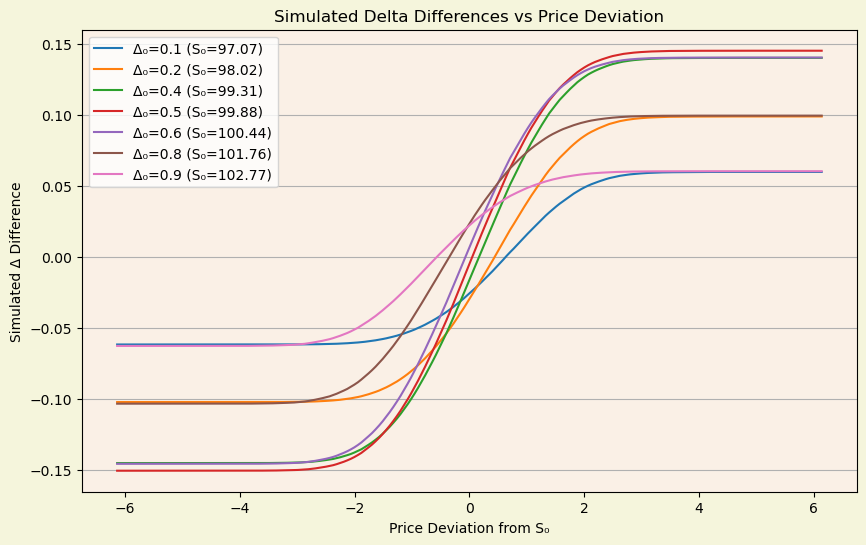

In [5]:
    # 1. Simulated Delta Differences vs Price Deviation
    df_sim = simulator.simulate_multiple(initial_deltas)
    fig, ax = simulator.default_canvas
    df_sim.plot(ax=ax)
    ax.set_xlabel("Price Deviation from S₀")
    ax.set_ylabel("Simulated Δ Difference")
    ax.set_title("Simulated Delta Differences vs Price Deviation")
    ax.grid(True, axis='y')
    plt.show()
    



Summary of Initial Greeks and Charm Effect:
               Implied S₀  Calculated Delta  Initial Gamma  Initial Charm
Initial Delta                                                            
0.1             97.067693               0.1       0.081237      -0.027111
0.2             98.022748               0.2       0.128331      -0.033334
0.4             99.314545               0.4       0.174791      -0.018872
0.5             99.876105               0.5       0.179476      -0.005590
0.6            100.440839               0.6       0.172830       0.008228
0.8            101.764504               0.8       0.123612       0.026859
0.9            102.765771               0.9       0.076733       0.024019


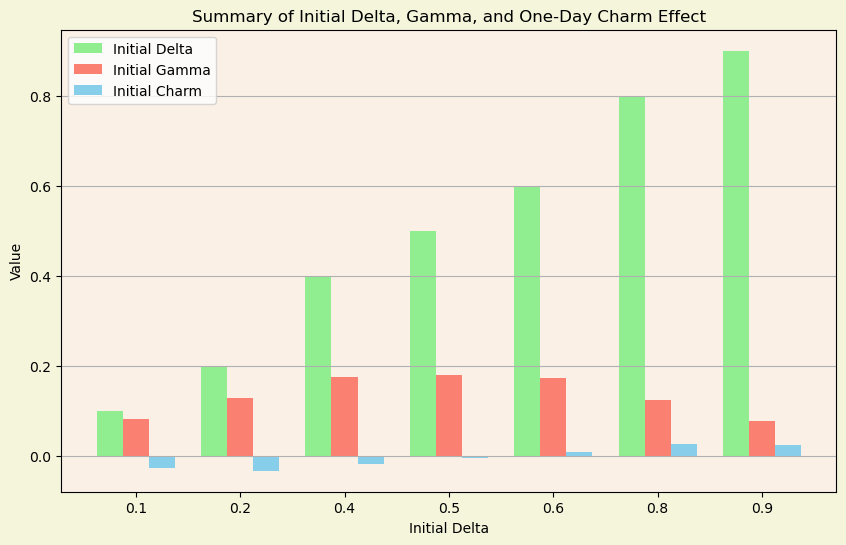

In [6]:
    # 2. Summary of Initial Greeks and Charm Effect
    summary_df = simulator.summary_initial_greeks(initial_deltas)
    print("\nSummary of Initial Greeks and Charm Effect:")
    print(summary_df)
    fig, ax = simulator.default_canvas
    width = 0.25
    x = np.arange(len(summary_df))
    ax.bar(x - width, summary_df["Calculated Delta"], width, label="Initial Delta", color='lightgreen')
    ax.bar(x, summary_df["Initial Gamma"], width, label="Initial Gamma", color='salmon')
    ax.bar(x + width, summary_df["Initial Charm"], width, label="Initial Charm", color='skyblue')
    ax.set_xlabel("Initial Delta")
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df.index.round(2))
    ax.set_ylabel("Value")
    ax.set_title("Summary of Initial Delta, Gamma, and One-Day Charm Effect")
    ax.legend()
    ax.grid(True, axis='y')
    plt.show()
    


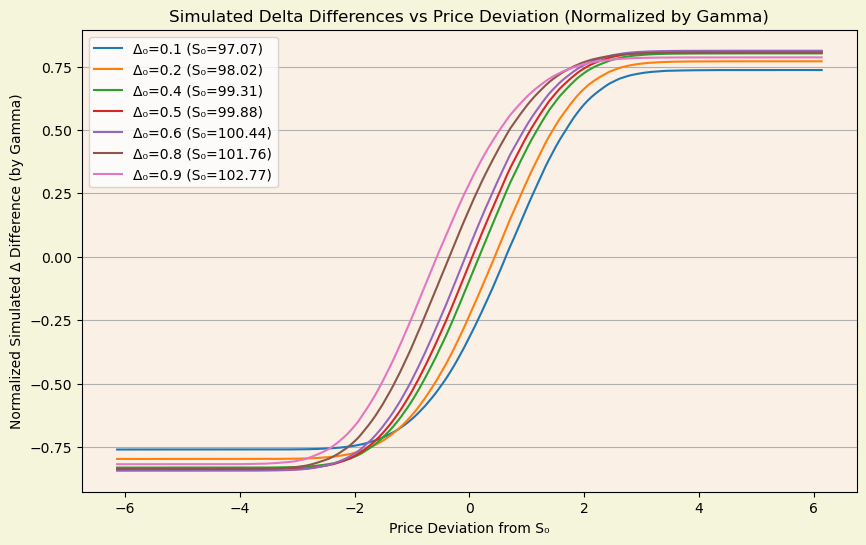

In [7]:
    # 3. Simulated Delta Differences vs Price Deviation (Normalized by Gamma)
    normalized_df = df_sim.copy()
    for d in initial_deltas:
        key = f"Δ₀={d} (S₀={simulator._implied_S0(d):.2f})"
        gamma_val = simulator.gamma(simulator._implied_S0(d), simulator.T)
        normalized_df[key] = normalized_df[key] / gamma_val
    fig, ax = simulator.default_canvas
    normalized_df.plot(ax=ax)
    ax.set_xlabel("Price Deviation from S₀")
    ax.set_ylabel("Normalized Simulated Δ Difference (by Gamma)")
    ax.set_title("Simulated Delta Differences vs Price Deviation (Normalized by Gamma)")
    ax.grid(True, axis='y')
    plt.show()
    


Implied initial S0 from Δ0=0.10: 97.068
Implied initial S0 from Δ0=0.20: 98.023
Implied initial S0 from Δ0=0.40: 99.315
Implied initial S0 from Δ0=0.50: 99.876
Implied initial S0 from Δ0=0.60: 100.441
Implied initial S0 from Δ0=0.80: 101.765
Implied initial S0 from Δ0=0.90: 102.766

Gamma-Charm vs Simulation at 5-sigma Move:
                       S₀  5-Sigma Move  Simulated Δ Change  Gamma-Charm Approx  Difference
Initial Delta                                                                              
0.1             97.067693      0.049765           -0.022224           -0.020403   -0.001821
0.2             98.022748      0.049765           -0.023396           -0.020295   -0.003101
0.4             99.314545      0.049765           -0.006706           -0.005393   -0.001313
0.5             99.876105      0.049765            0.004977            0.004487    0.000490
0.6            100.440839      0.049765            0.016269            0.014085    0.002185
0.8            101.764504    

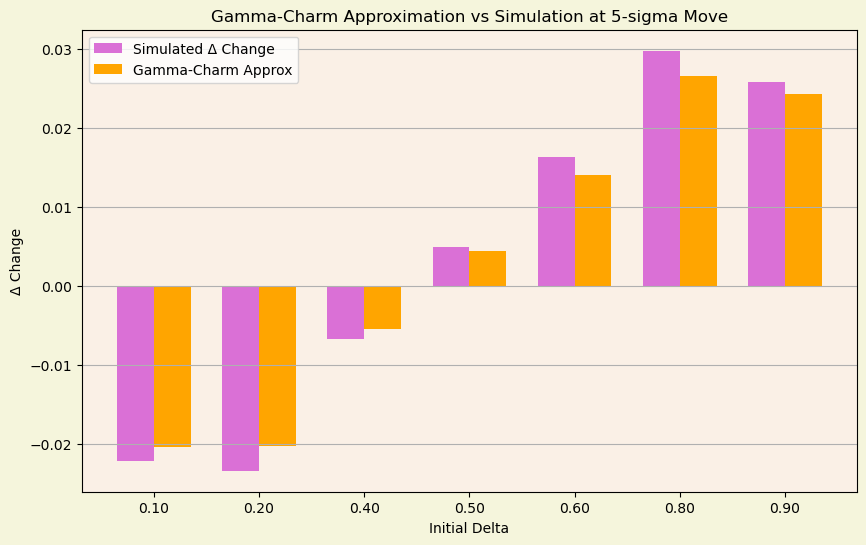

In [8]:
    # 4. Gamma-Charm Approximation vs Simulation at 5-sigma Move
    results_data = []
    for d in initial_deltas:
        S0 = simulator._implied_S0(d)
        sigma_d = simulator.sigma * np.sqrt(simulator.delta_t)
        dS_5sigma = 5 * sigma_d  # 5-sigma move
        sim_series = simulator.simulate(d)
        idx_closest = np.abs(sim_series.index - dS_5sigma).argmin()
        sim_value = sim_series.iloc[idx_closest]
        gamma_val = simulator.gamma(S0, simulator.T)
        charm_val = simulator.charm(S0, simulator.T - 0 * simulator.delta_t)
        approx_value = gamma_val * dS_5sigma + charm_val * simulator.delta_t
        diff = sim_value - approx_value
        results_data.append({
            "Initial Delta": d,
            "S₀": S0,
            "5-Sigma Move": dS_5sigma,
            "Simulated Δ Change": sim_value,
            "Gamma-Charm Approx": approx_value,
            "Difference": diff
        })
    df_5sigma = pd.DataFrame(results_data).set_index("Initial Delta")
    print("\nGamma-Charm vs Simulation at 5-sigma Move:")
    print(df_5sigma)
    fig, ax = simulator.default_canvas
    width = 0.35
    x = np.arange(len(df_5sigma))
    ax.bar(x - width/2, df_5sigma["Simulated Δ Change"], width, label="Simulated Δ Change", color='orchid')
    ax.bar(x + width/2, df_5sigma["Gamma-Charm Approx"], width, label="Gamma-Charm Approx", color='orange')
    ax.set_xlabel("Initial Delta")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{d:.2f}" for d in df_5sigma.index])
    ax.set_ylabel("Δ Change")
    ax.set_title("Gamma-Charm Approximation vs Simulation at 5-sigma Move")
    ax.legend()
    ax.grid(True, axis='y')
    plt.show()
        


In [12]:
    # 5. Normalized Comparison using Gamma-Charm Ratio
    # For each simulated series, compute
    #   R = (simulated Δ difference) / (γ(S₀,T)*dS + χ(S₀,T)*δt)


    for d in initial_deltas:
        S0 = simulator._implied_S0(d)
        # Evaluate gamma and charm at (S0, T) for the local expansion.
        gamma_val = simulator.gamma(S0, simulator.T)
        charm_val = simulator.charm(S0, simulator.T)
        
        # Get the simulated delta differences as a Series indexed by price deviation.
        sim_series = simulator.simulate(d)
        
        # For each price deviation (dS) in the series, the denominator is:
        # gamma_val * dS + charm_val * delta_t.
        # Compute R for every bin.
        R_series = sim_series / ( gamma_val * sim_series.index + charm_val * simulator.delta_t )
        
        # Plot the normalized ratio curve for this initial delta.
        # TODO: uncomment form top:
        # fig, ax = simulator.default_canvas
        # ax.plot(sim_series.index, R_series.values, label=f"Δ₀={d}")

    # ax.set_xlabel("Price Deviation from S₀")
    # ax.set_ylabel("Normalized Ratio R")
    # ax.set_title("Normalized Simulated Δ Differences vs Price Deviation\n(R = Δ_sim/(γ·dS + χ·Δt))")
    # ax.legend()
    # ax.grid(True, axis='y')
    # plt.show()


    


Implied initial S0 from Δ0=0.10: 97.068
Implied initial S0 from Δ0=0.20: 98.023
Implied initial S0 from Δ0=0.40: 99.315
Implied initial S0 from Δ0=0.50: 99.876
Implied initial S0 from Δ0=0.60: 100.441
Implied initial S0 from Δ0=0.80: 101.765
Implied initial S0 from Δ0=0.90: 102.766


In [13]:
sim_series.index

Index([ -6.137006037853382,  -6.034722603889165,  -5.932439169924933,  -5.830155735960702, -5.7278723019964985,  -5.625588868032267,   -5.52330543406805,  -5.421022000103818,  -5.318738566139601,  -5.216455132175369,
       ...
        5.2164551321753265,   5.318738566139544,   5.421022000103775,   5.523305434068007,   5.625588868032224,   5.727872301996456,   5.830155735960673,   5.932439169924905,   6.034722603889122,   6.137006037853354],
      dtype='float64', length=120)

Implied initial S0 from Δ0=0.10: 97.068
Implied initial S0 from Δ0=0.20: 98.023
Implied initial S0 from Δ0=0.40: 99.315
Implied initial S0 from Δ0=0.50: 99.876
Implied initial S0 from Δ0=0.60: 100.441
Implied initial S0 from Δ0=0.80: 101.765
Implied initial S0 from Δ0=0.90: 102.766


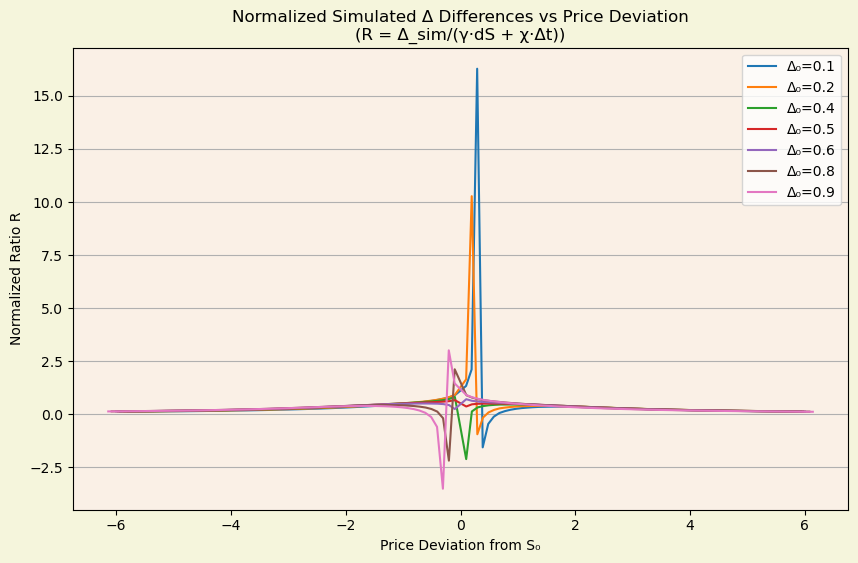

Implied initial S0 from Δ0=0.10: 97.068
Implied initial S0 from Δ0=0.20: 98.023
Implied initial S0 from Δ0=0.40: 99.315
Implied initial S0 from Δ0=0.50: 99.876
Implied initial S0 from Δ0=0.60: 100.441
Implied initial S0 from Δ0=0.80: 101.765
Implied initial S0 from Δ0=0.90: 102.766


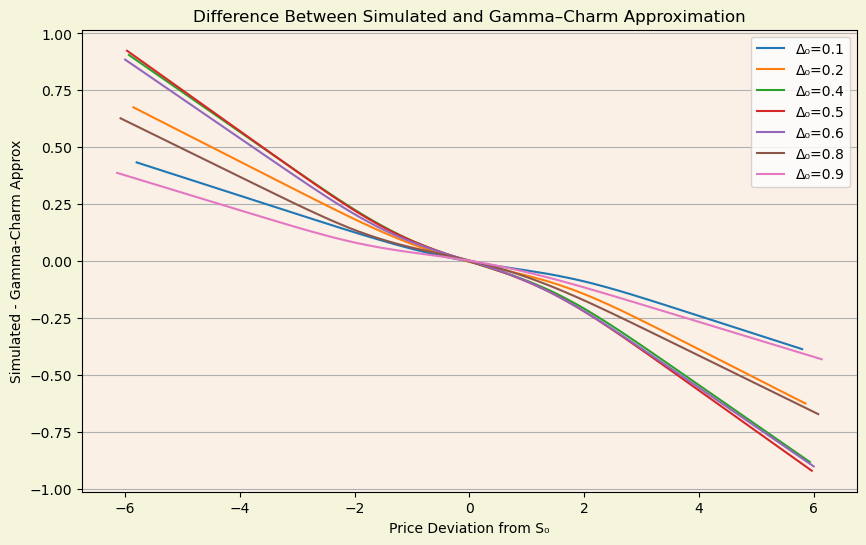

In [14]:

    # 5.b. Normalized Comparison using Gamma-Charm Ratio (Plot Each Curve Directly)
    fig, ax = simulator.default_canvas

    for d in initial_deltas:
        S0 = simulator._implied_S0(d)
        # Compute gamma and charm evaluated at S0 at time T
        gamma_val = simulator.gamma(S0, simulator.T)
        charm_val = simulator.charm(S0, simulator.T)  # using t0 = T as per the formulation
        # Run simulation for this initial delta
        sim_series = simulator.simulate(d)
        # For each price deviation dS, compute denominator = gamma_val*dS + charm_val*delta_t
        denom = gamma_val * sim_series.index + charm_val * simulator.delta_t
        R_series = sim_series / denom
        ax.plot(sim_series.index, R_series.values, label=f"Δ₀={d}")

    ax.set_xlabel("Price Deviation from S₀")
    ax.set_ylabel("Normalized Ratio R")
    ax.set_title("Normalized Simulated Δ Differences vs Price Deviation\n(R = Δ_sim/(γ·dS + χ·Δt))")
    ax.legend()
    ax.grid(True, axis='y')
    plt.show()

    # 6. Difference Between Simulated and Gamma–Charm Approximation
    fig, ax = simulator.default_canvas

    for d in initial_deltas:
        S0 = simulator._implied_S0(d)
        # Evaluate gamma and charm at (S0, T) for the local expansion around initial conditions
        gamma_val = simulator.gamma(S0, simulator.T)
        charm_val = simulator.charm(S0, simulator.T)

        # Simulated delta differences as a Series indexed by price deviation dS
        sim_series = simulator.simulate(d)

        # Gamma–charm approximation for each bin: gamma_val*dS + charm_val*delta_t
        approx_series = gamma_val * sim_series.index + charm_val * simulator.delta_t

        # Difference: (Simulated) - (Gamma–Charm Approx)
        diff_series = sim_series - approx_series

        # Plot each difference series directly on the same axes
        ax.plot(diff_series.index, diff_series.values, label=f"Δ₀={d}")

    ax.set_xlabel("Price Deviation from S₀")
    ax.set_ylabel("Simulated - Gamma-Charm Approx")
    ax.set_title("Difference Between Simulated and Gamma–Charm Approximation")
    ax.legend()
    ax.grid(True, axis='y')
    plt.show()

